In [1]:
!pip install -q tensorflow scikit-learn matplotlib seaborn pillow

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


In [3]:
!git clone --depth 1 https://github.com/spMohanty/PlantVillage-Dataset.git

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163219, done.
remote: Counting objects: 100% (163219/163219), done.
remote: Compressing objects: 100% (163125/163125), done.
remote: Total 163219 (delta 93), reused 163215 (delta 93), pack-reused 0 (from 0)
Receiving objects: 100% (163219/163219), 2.00 GiB | 21.98 MiB/s, done.
Resolving deltas: 100% (93/93), done.
Updating files: 100% (182404/182404), done.


In [4]:
from pathlib import Path

root = Path("/content/PlantVillage-Dataset")

for path in root.rglob("*"):
    if path.is_dir() and "Tomato" in path.name:
        print(path)

/content/PlantVillage-Dataset/raw/color/Tomato___Tomato_mosaic_virus
/content/PlantVillage-Dataset/raw/color/Tomato___Leaf_Mold
/content/PlantVillage-Dataset/raw/color/Tomato___Bacterial_spot
/content/PlantVillage-Dataset/raw/color/Tomato___Early_blight
/content/PlantVillage-Dataset/raw/color/Tomato___Target_Spot
/content/PlantVillage-Dataset/raw/color/Tomato___healthy
/content/PlantVillage-Dataset/raw/color/Tomato___Late_blight
/content/PlantVillage-Dataset/raw/color/Tomato___Tomato_Yellow_Leaf_Curl_Virus
/content/PlantVillage-Dataset/raw/color/Tomato___Spider_mites Two-spotted_spider_mite
/content/PlantVillage-Dataset/raw/color/Tomato___Septoria_leaf_spot
/content/PlantVillage-Dataset/raw/grayscale/Tomato___Tomato_mosaic_virus
/content/PlantVillage-Dataset/raw/grayscale/Tomato___Leaf_Mold
/content/PlantVillage-Dataset/raw/grayscale/Tomato___Bacterial_spot
/content/PlantVillage-Dataset/raw/grayscale/Tomato___Early_blight
/content/PlantVillage-Dataset/raw/grayscale/Tomato___Target_Spot

In [5]:
from pathlib import Path

DATA_DIR = Path(
    "/content/PlantVillage-Dataset/raw/color"
)

SELECTED_CLASSES = [
    "Tomato___healthy",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot"
]

# Verify that all selected folders exist
for class_name in SELECTED_CLASSES:
    class_dir = DATA_DIR / class_name
    assert class_dir.is_dir(), f"Missing folder: {class_dir}"
    print(f"{class_name}: folder found")

print("\nDataset path verified successfully!")

Tomato___healthy: folder found
Tomato___Early_blight: folder found
Tomato___Late_blight: folder found
Tomato___Leaf_Mold: folder found
Tomato___Septoria_leaf_spot: folder found

Dataset path verified successfully!


In [6]:
from collections import Counter

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

image_counts = {}

for class_name in SELECTED_CLASSES:
    class_dir = DATA_DIR / class_name

    images = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    image_counts[class_name] = len(images)

for name, count in image_counts.items():
    print(f"{name}: {count} images")

print("\nTotal images:", sum(image_counts.values()))

Tomato___healthy: 1591 images
Tomato___Early_blight: 1000 images
Tomato___Late_blight: 1909 images
Tomato___Leaf_Mold: 952 images
Tomato___Septoria_leaf_spot: 1771 images

Total images: 7223


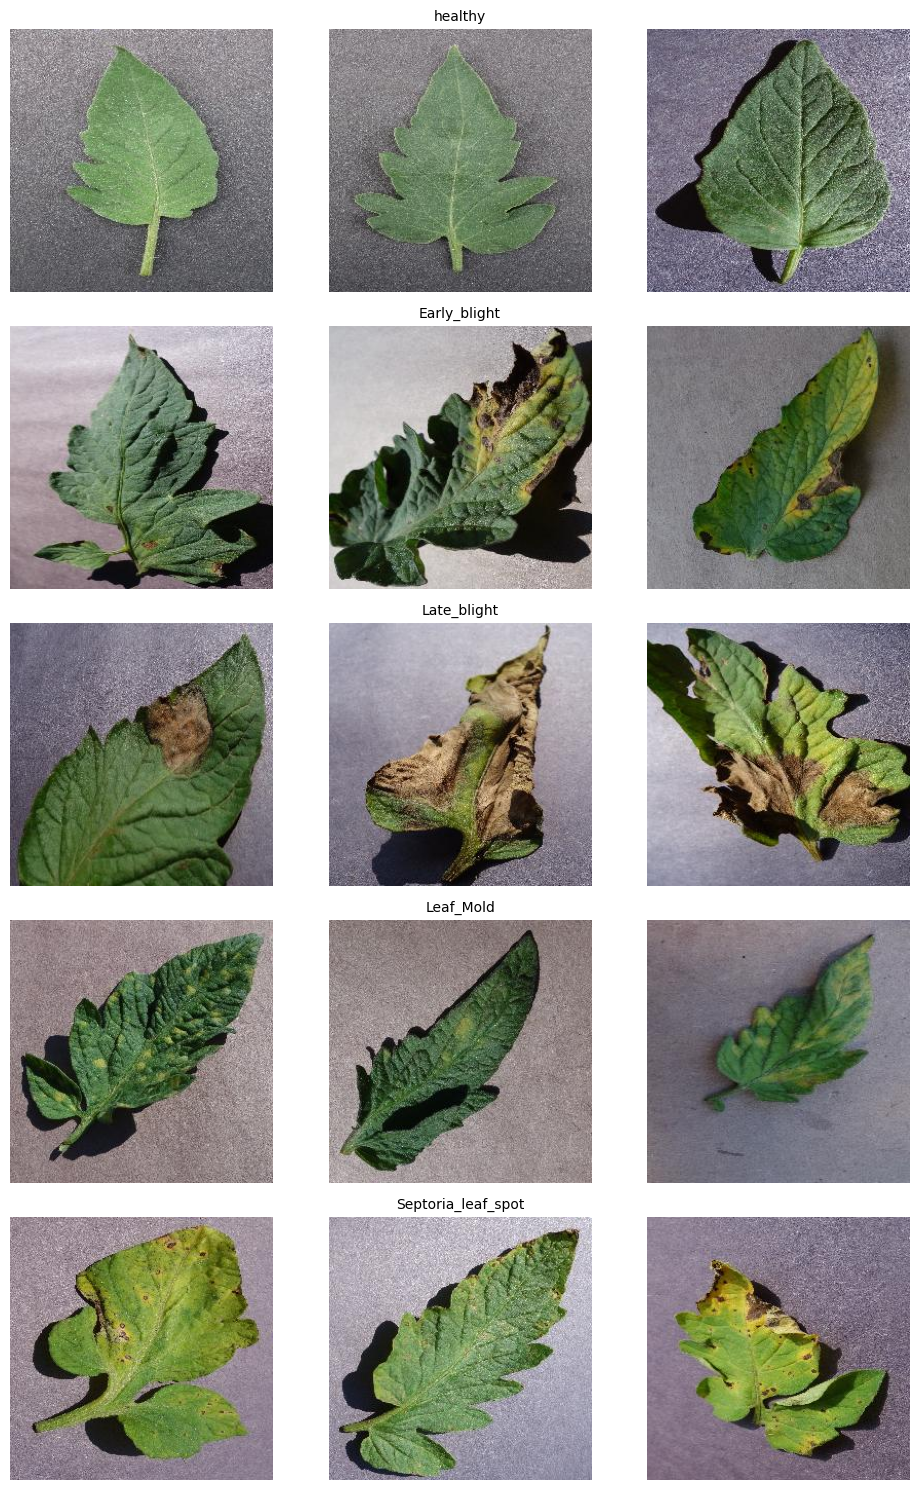

In [8]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

fig, axes = plt.subplots(
    nrows=5, ncols=3, figsize=(10, 15)
)

for row, class_name in enumerate(SELECTED_CLASSES):
    class_dir = DATA_DIR / class_name

    images = [
        p for p in class_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for col in range(3):
        image_path = random.choice(images)
        image = Image.open(image_path).convert("RGB")

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 1:
            axes[row, col].set_title(
                class_name.replace("Tomato___", ""),
                fontsize=10
            )

plt.tight_layout()
plt.show()

In [9]:
import shutil
from sklearn.model_selection import train_test_split

SPLIT_DIR = Path("/content/plant_disease_split")

# Remove an earlier split if you rerun this cell
if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

for split in ["train", "val", "test"]:
    for class_name in SELECTED_CLASSES:
        (SPLIT_DIR / split / class_name).mkdir(
            parents=True, exist_ok=True
        )

for class_name in SELECTED_CLASSES:
    class_dir = DATA_DIR / class_name

    files = sorted([
        p for p in class_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    # 70% train, 30% temporary
    train_files, temp_files = train_test_split(
        files,
        test_size=0.30,
        random_state=42
    )

    # Split the remaining 30% equally
    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42
    )

    for split, split_files in [
        ("train", train_files),
        ("val", val_files),
        ("test", test_files)
    ]:
        for source in split_files:
            shutil.copy2(
                source,
                SPLIT_DIR / split / class_name / source.name
            )

    print(
        f"{class_name}: "
        f"train={len(train_files)}, "
        f"val={len(val_files)}, "
        f"test={len(test_files)}"
    )

print("\nDataset splitting completed!")

Tomato___healthy: train=1113, val=239, test=239
Tomato___Early_blight: train=700, val=150, test=150
Tomato___Late_blight: train=1336, val=286, test=287
Tomato___Leaf_Mold: train=666, val=143, test=143
Tomato___Septoria_leaf_spot: train=1239, val=266, test=266

Dataset splitting completed!


In [10]:
for split in ["train", "val", "test"]:
    total = sum(
        1 for p in (SPLIT_DIR / split).rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

    print(f"{split.upper()}: {total} images")

TRAIN: 5054 images
VAL: 1084 images
TEST: 1085 images


In [11]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLIT_DIR / "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLIT_DIR / "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    str(SPLIT_DIR / "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

assert len(class_names) == 5
assert class_names == sorted(SELECTED_CLASSES)

Found 5054 files belonging to 5 classes.
Found 1084 files belonging to 5 classes.
Found 1085 files belonging to 5 classes.
Classes: ['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy']
Number of classes: 5


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Datasets loaded and prefetching configured.")

Datasets loaded and prefetching configured.


In [13]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    # Normalize pixel values from 0-255 to 0-1
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from pathlib import Path

CHECKPOINT_PATH = "/content/best_model.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4282 - loss: 1.3438
Epoch 1: val_loss improved from None to 0.64114, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.5742 - loss: 1.0640 - val_accuracy: 0.7685 - val_loss: 0.6411 - learning_rate: 0.0010
Epoch 2/15
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7657 - loss: 0.6068
Epoch 2: val_loss improved from 0.64114 to 0.44572, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7960 - loss: 0.5346 - val_accuracy: 0.8598 - val_loss: 0.4457 - learning_rate: 0.0010
Epoch 3/15
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8088 - loss: 0.4908
Epoch 3: val_loss did not improve from 0.44572
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8366 - loss: 0.4361 - val_accuracy: 0.8210 -

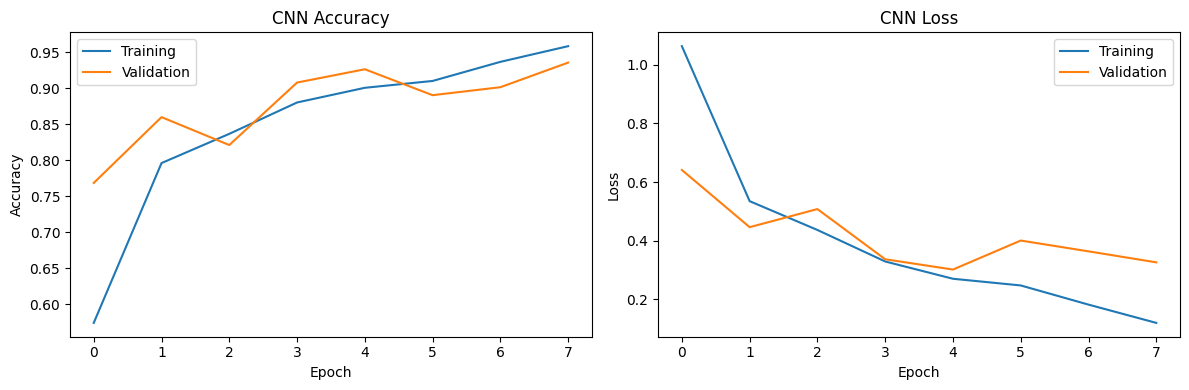

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Training")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Training")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/training_history.png", dpi=150)
plt.show()

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.9069 - loss: 0.2553

Test Loss: 0.2553
Test Accuracy: 90.69%
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

Classification Report:

                             precision    recall  f1-score   support

      Tomato___Early_blight       0.83      0.83      0.83       150
       Tomato___Late_blight       0.95      0.85      0.89       287
         Tomato___Leaf_Mold       0.85      0.90      0.88       143
Tomato___Septoria_leaf_spot       0.88      0.94      0.91       266
           Tomato___healthy       0.98      0.99      0.99       239

                   accuracy                           0.91      1085
                  macro avg       0.90      0.90      0.90      1085
               weighted avg       0.91      0.91      0.91      1085



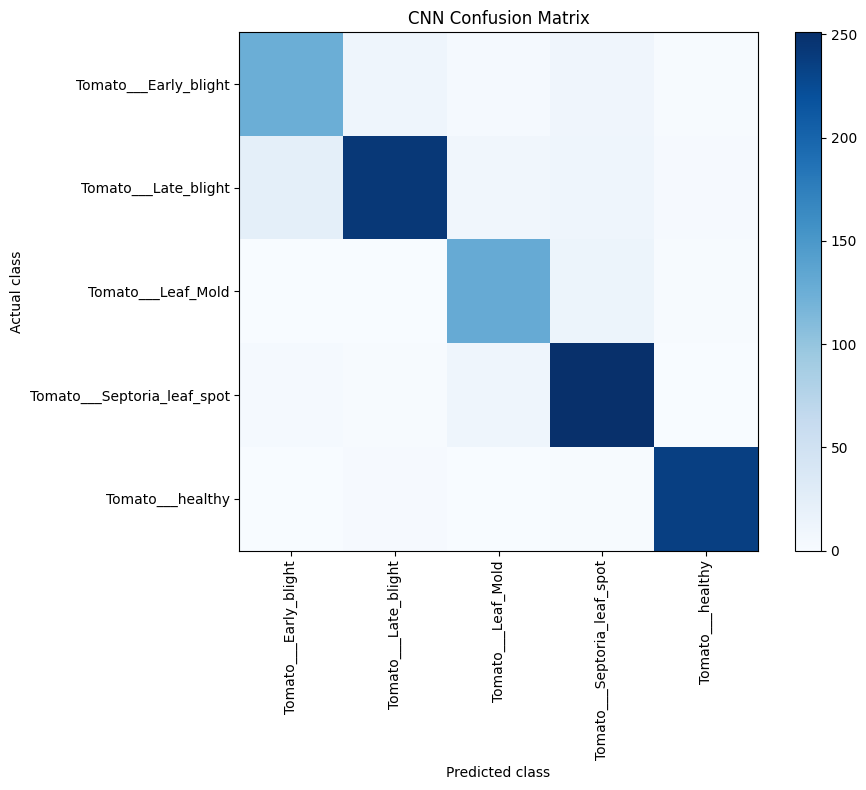

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

best_model = tf.keras.models.load_model(CHECKPOINT_PATH)

test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

y_true = np.concatenate([
    labels.numpy() for _, labels in test_ds
])

y_prob = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(class_names)))
)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()

In [17]:
import json

EXPORT_DIR = Path("/content/exported_model")
EXPORT_DIR.mkdir(exist_ok=True)

best_model.save(
    str(EXPORT_DIR / "plant_disease_cnn.keras")
)

with open(EXPORT_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)

print("Model and class names exported successfully.")
print(list(EXPORT_DIR.iterdir()))

Model and class names exported successfully.
[PosixPath('/content/exported_model/plant_disease_cnn.keras'), PosixPath('/content/exported_model/class_names.json')]
